Loaded: ../../model_dev_main/index_files/min400PM_wind_drift_SAR_dataset_wBackwardPastDrift/sar_hist_train.npz
Channels: ['sar_hh_db', 'sar_hv_db']
Histogram bins: 281
Batches used for PDF band stats: 1412
Meta (summary):
   sar_hh_db  p1= -18.88 dB   p99=  -7.12 dB
   sar_hv_db  p1= -34.88 dB   p99= -17.88 dB


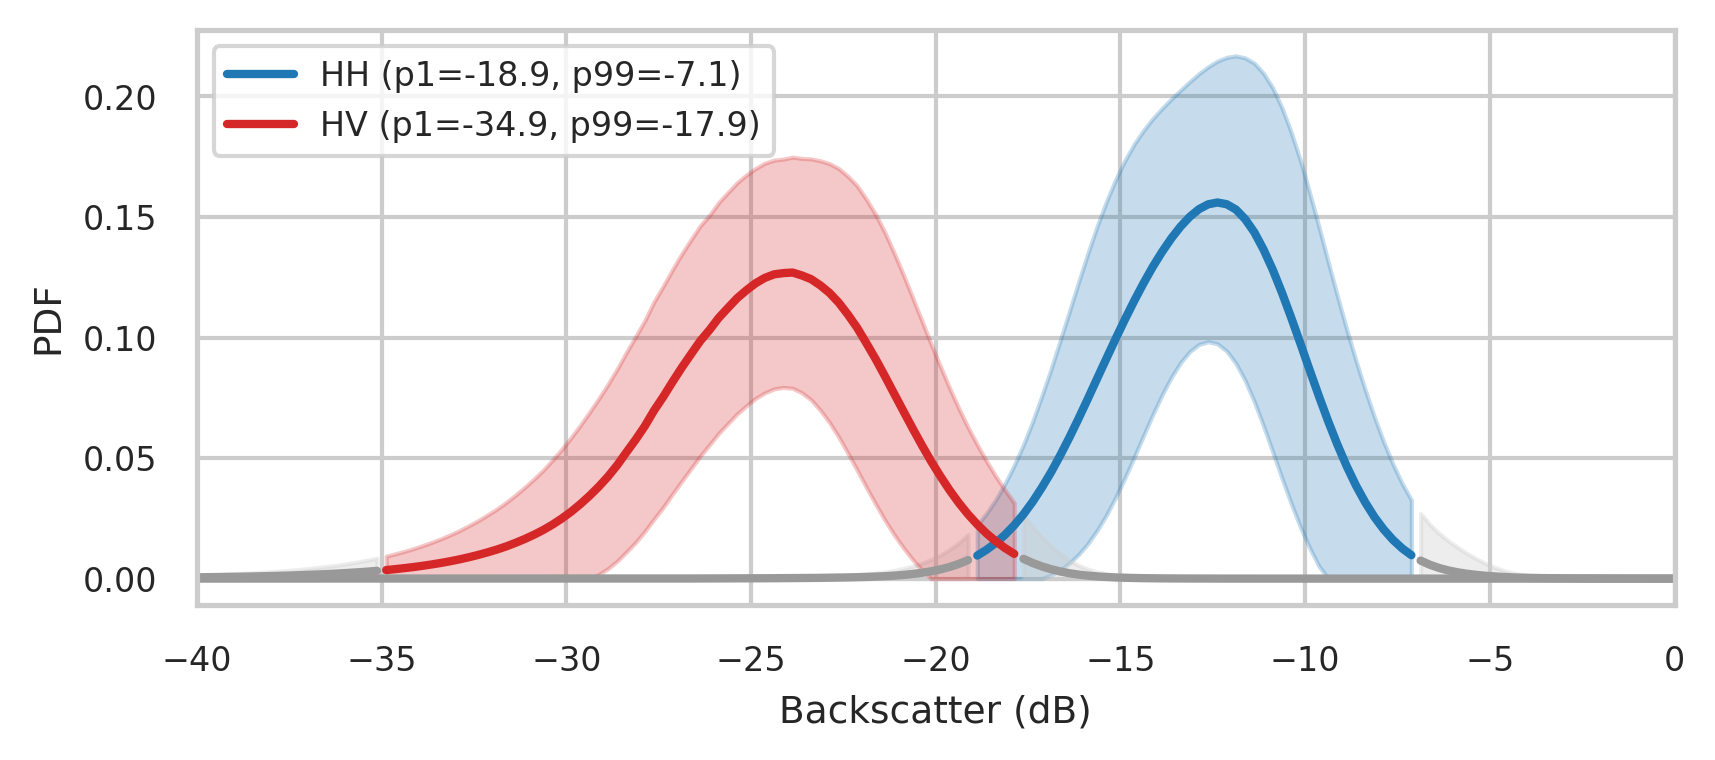

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

NPZ_PATH = "../../model_dev_main/index_files/min400PM_wind_drift_SAR_dataset_wBackwardPastDrift/sar_hist_train.npz"

TEXTWIDTH_PT = 418.25368
TEXTWIDTH_IN = TEXTWIDTH_PT / 72.27

def setup_pub_style(fontsize=9):
    sns.set_theme(style="whitegrid", palette="colorblind")
    mpl.rcParams.update({
        "font.size": fontsize,
        "axes.titlesize": fontsize,
        "axes.labelsize": fontsize,
        "xtick.labelsize": fontsize - 1,
        "ytick.labelsize": fontsize - 1,
        "legend.fontsize": fontsize - 1,
        "figure.dpi": 300,
        "savefig.dpi": 300,
    })

def fig_textwidth(height_ratio=0.5):
    return plt.subplots(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * height_ratio))

setup_pub_style(fontsize=9)

def percentile_from_cdf(bin_centers, cdf_row, q):
    target = q / 100.0
    i = np.searchsorted(cdf_row, target, side="left")
    i = int(np.clip(i, 0, len(bin_centers) - 1))
    return float(bin_centers[i])

def clean_name(name):
    n = name.lower()
    if "hh" in n:
        return "HH"
    elif "hv" in n:
        return "HV"
    return name

d = np.load(NPZ_PATH, allow_pickle=True)

names   = [str(x) for x in d["channel_names"]]
names_clean = [clean_name(n) for n in names]
centers = d["bin_centers_db"]
pdf     = d["pdf"]
cdf     = d["cdf"]

pdf_mean = d["pdf_mean_across_batches"]
pdf_std  = d["pdf_std_across_batches"]
n_batches_used = int(d["n_batches_used_for_pdf_stats"]) if "n_batches_used_for_pdf_stats" in d else None

meta = d["meta"]

print("Loaded:", NPZ_PATH)
print("Channels:", names)
print("Histogram bins:", len(centers))
if n_batches_used is not None:
    print("Batches used for PDF band stats:", n_batches_used)

print("Meta (summary):")
for k in ["index_path", "dataset_len", "sar_to_db", "db_min", "db_max", "db_step", "n_valid_pixels_per_channel"]:
    if k in meta:
        print(f"  {k}: {meta[k]}")

# Percentiles from global CDF
p1s, p99s = [], []
for ci, name in enumerate(names):
    p1  = percentile_from_cdf(centers, cdf[ci], 1)
    p99 = percentile_from_cdf(centers, cdf[ci], 99)
    p1s.append(p1)
    p99s.append(p99)
    print(f"{name:>12s}  p1={p1:7.2f} dB   p99={p99:7.2f} dB")

fig, ax = fig_textwidth(height_ratio=0.45)

colors = ["#1f77b4", "#d62728"]   # ← set your colors here

for ci, name in enumerate(names):
    p1, p99 = p1s[ci], p99s[ci]

    inside = (centers >= p1) & (centers <= p99)
    left_tail  = centers < p1
    right_tail = centers > p99

    line, = ax.plot(
        centers[inside],
        pdf[ci][inside],
        linewidth=2,
        color=colors[ci],          # ← use it here
        label=f"{names_clean[ci]} (p1={p1:.1f}, p99={p99:.1f})"
    )
    color = colors[ci]             # ← and replace line.get_color() with this

    ax.plot(centers[left_tail],  pdf[ci][left_tail],  linewidth=2, color="0.6")
    ax.plot(centers[right_tail], pdf[ci][right_tail], linewidth=2, color="0.6")

    lo = np.clip(pdf_mean[ci] - pdf_std[ci], 0.0, None)
    hi = pdf_mean[ci] + pdf_std[ci]

    ax.fill_between(centers, lo, hi, where=inside, color=color, alpha=0.25)
    ax.fill_between(centers, lo, hi, where=left_tail,  color="0.8", alpha=0.35)
    ax.fill_between(centers, lo, hi, where=right_tail, color="0.8", alpha=0.35)

ax.set_xlabel("Backscatter (dB)")
ax.set_ylabel("PDF")
ax.set_xlim(-40, 0)
ax.legend(frameon=True, loc="upper left", fontsize=8)
fig.tight_layout()
plt.savefig("sar_pdf_with_bands.pdf")
plt.show()